This project performs a comparative complaint pattern analysis between two major competitors: Gojek and Grab. Using NLP techniques such as text preprocessing, TF-IDF, and topic modeling, we identify dominant complaint themes and evaluate platform performance from a customer perspective based from google play store review.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Example path
df = pd.read_csv('/content/drive/MyDrive/Data Analysis/Colab Notebooks/gojek_grab_reviews (3).csv')


Mounted at /content/drive


In [ ]:
# Preview data
df.head()

# Shape
print("Dataset shape:", df.shape)

# Info
df.info()

# Missing values
df.isnull().sum()

# Unique platforms
df['platform'].value_counts()

# Rating distribution
df['rating'].value_counts().sort_index()


Dataset shape: (10000, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   platform    10000 non-null  object
 1   review      10000 non-null  object
 2   rating      10000 non-null  int64 
 3   engagement  10000 non-null  int64 
 4   date        10000 non-null  object
dtypes: int64(2), object(3)
memory usage: 390.8+ KB


,count
rating,
1,2667
2,433
3,407
4,469
5,6024


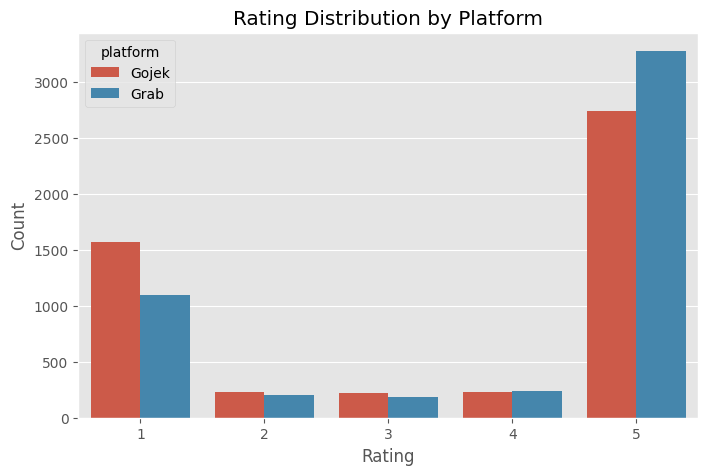

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='rating', hue='platform')
plt.title("Rating Distribution by Platform")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


In [ ]:
df.groupby('platform')['rating'].mean()


,rating
platform,
Gojek,3.47
Grab,3.88


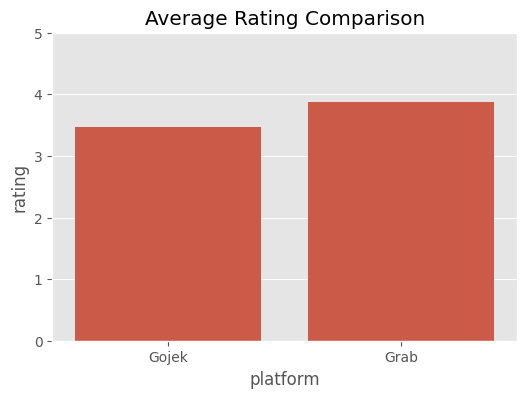

In [ ]:
avg_rating = df.groupby('platform')['rating'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=avg_rating, x='platform', y='rating')
plt.title("Average Rating Comparison")
plt.ylim(0,5)
plt.show()


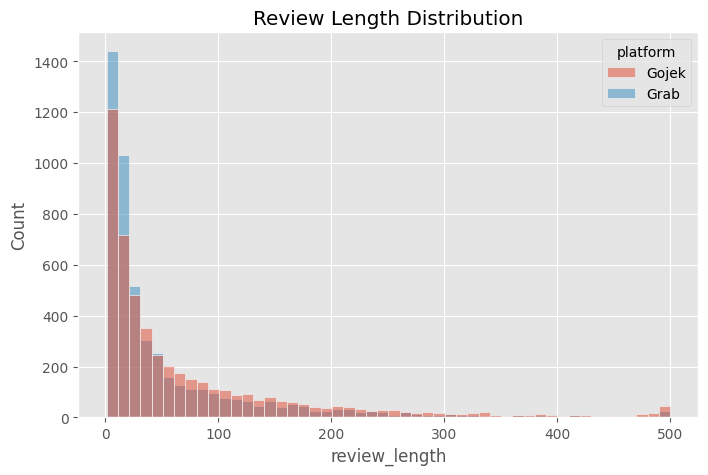

In [ ]:
df['review_length'] = df['review'].astype(str).apply(len)

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='review_length', hue='platform', bins=50)
plt.title("Review Length Distribution")
plt.show()


NLP

In [ ]:
!pip install Sastrawi
!pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.2 MB/s eta 0:00:00


In [ ]:
import re
import string
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from wordcloud import WordCloud

nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)  # remove url
    text = re.sub(r"\@\w+", "", text)  # remove mention
    text = re.sub(r"#\w+", "", text)  # remove hashtag
    text = re.sub(r"\d+", "", text)  # remove number
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['clean_review'] = df['review'].apply(clean_text)


In [ ]:
stop_words = set(stopwords.words('indonesian'))

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['clean_review'] = df['clean_review'].apply(remove_stopwords)


In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(text):
    return stemmer.stem(text)

df['clean_review'] = df['clean_review'].apply(stemming)


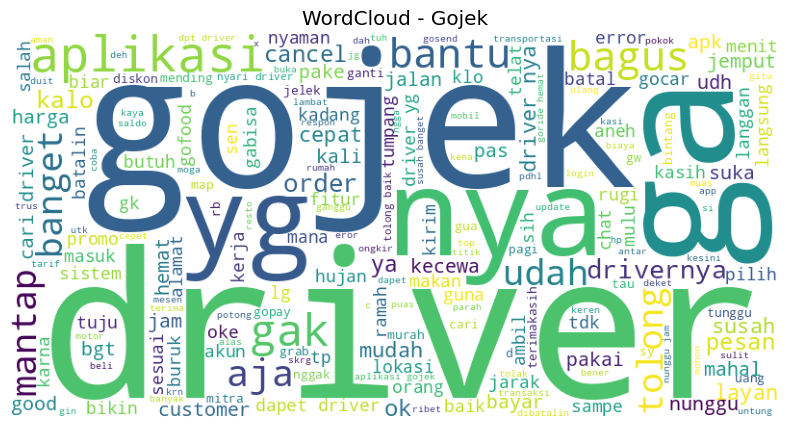

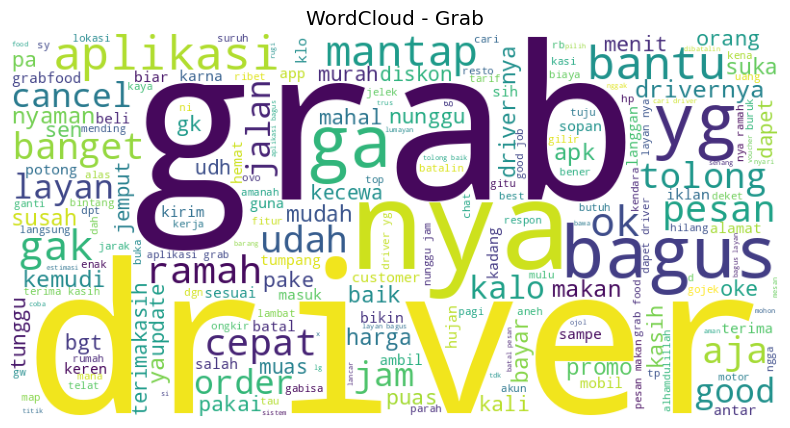

In [ ]:
def plot_wordcloud(platform_name):
    text = " ".join(df[df['platform']==platform_name]['clean_review'])
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wc)
    plt.axis('off')
    plt.title(f"WordCloud - {platform_name}")
    plt.show()

plot_wordcloud('Gojek')
plot_wordcloud('Grab')


In [ ]:
def sentiment_label(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df['sentiment'] = df['rating'].apply(sentiment_label)

df['sentiment'].value_counts()


,count
sentiment,
Positive,6493
Negative,3100
Neutral,407


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_review'])
y = df['sentiment']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.859
              precision    recall  f1-score   support

    Negative       0.78      0.84      0.81       628
     Neutral       0.00      0.00      0.00        99
    Positive       0.90      0.93      0.92      1273

    accuracy                           0.86      2000
   macro avg       0.56      0.59      0.58      2000
weighted avg       0.82      0.86      0.84      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


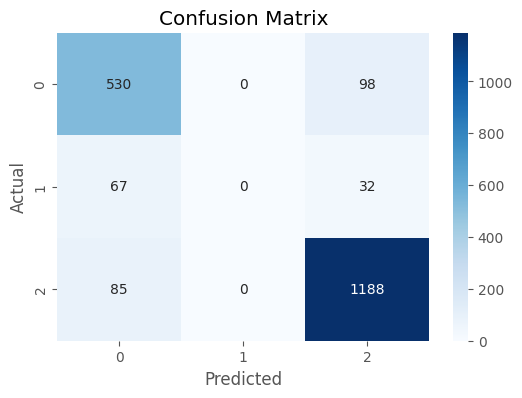

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_

for i, class_label in enumerate(model.classes_):
    top10 = np.argsort(coefficients[i])[-10:]
    print(f"\nTop words for {class_label}:")
    print([feature_names[j] for j in top10])



Top words for Negative:
['tolol', 'jam', 'sampah', 'up', 'parah', 'cs', 'mulu', 'jelek', 'buruk', 'ga']

Top words for Neutral:
['jdi', 'telat', 'lambat', 'menit', 'error', 'tpi', 'update', 'maps', 'tolong', 'lokasi']

Top words for Positive:
['muas', 'ok', 'bagus', 'terimakasih', 'oke', 'mudah', 'good', 'ramah', 'mantap', 'bantu']


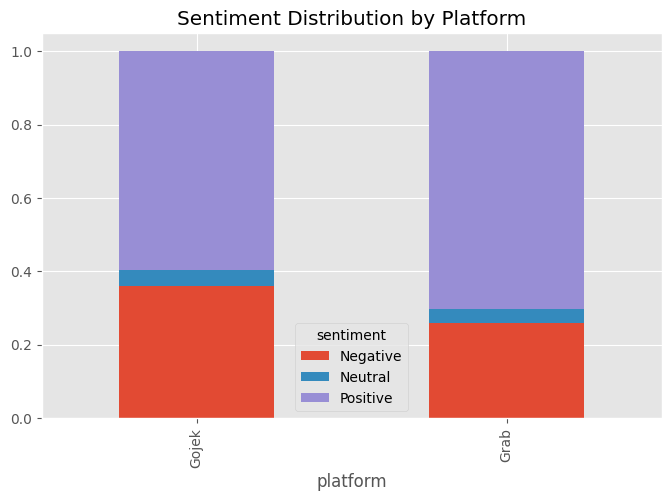

In [ ]:
platform_sentiment = pd.crosstab(df['platform'], df['sentiment'], normalize='index')
platform_sentiment

platform_sentiment.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Sentiment Distribution by Platform")
plt.show()

In [ ]:
import pandas as pd

contingency_table = pd.crosstab(df['platform'], df['sentiment'])
contingency_table


sentiment,Negative,Neutral,Positive
platform,,,
Gojek,1801,221,2978
Grab,1299,186,3515


In [ ]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Value:", chi2)
print("P-Value:", p)
print("Degrees of Freedom:", dof)


Chi-Square Value: 128.7137310716862
P-Value: 1.1224536724130428e-28
Degrees of Freedom: 2


In [ ]:
import numpy as np

n = contingency_table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape)-1)))

print("Cramér's V:", cramers_v)


Cramér's V: 0.11345207405406312


In [ ]:
!pip install gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 44.3 MB/s eta 0:00:00


In [ ]:
import gensim
from gensim import corpora
from gensim.models import LdaModel


In [ ]:
def run_lda(platform_name, num_topics=3):

    subset = df[df['platform'] == platform_name]['clean_review']

    texts = [text.split() for text in subset]

    dictionary = corpora.Dictionary(texts)
    corpus = [dictionary.doc2bow(text) for text in texts]

    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=10
    )

    print(f"\nTopics for {platform_name}:")
    for idx, topic in lda_model.print_topics(-1):
        print(f"Topic {idx}: {topic}")


In [ ]:
run_lda('Gojek')
run_lda('Grab')



Topics for Gojek:
Topic 0: 0.027*"bantu" + 0.027*"bagus" + 0.026*"gojek" + 0.016*"aplikasi" + 0.015*"gak" + 0.013*"mudah" + 0.011*"nya" + 0.011*"driver" + 0.011*"jam" + 0.011*"ga"
Topic 1: 0.037*"driver" + 0.034*"yg" + 0.018*"ok" + 0.016*"layan" + 0.013*"gojek" + 0.011*"nya" + 0.009*"cepat" + 0.009*"oke" + 0.009*"ga" + 0.008*"tolong"
Topic 2: 0.041*"driver" + 0.024*"aplikasi" + 0.022*"nya" + 0.020*"ga" + 0.019*"gojek" + 0.013*"mantap" + 0.013*"susah" + 0.013*"banget" + 0.012*"dapet" + 0.011*"gak"

Topics for Grab:
Topic 0: 0.032*"ok" + 0.032*"cepat" + 0.027*"grab" + 0.014*"mudah" + 0.013*"pesan" + 0.012*"puas" + 0.011*"layan" + 0.011*"bayar" + 0.009*"makan" + 0.009*"ovo"
Topic 1: 0.039*"driver" + 0.038*"nya" + 0.033*"bagus" + 0.022*"grab" + 0.021*"ramah" + 0.017*"yg" + 0.013*"layan" + 0.012*"gak" + 0.011*"ga" + 0.010*"tolong"
Topic 2: 0.028*"bantu" + 0.027*"aplikasi" + 0.023*"grab" + 0.021*"mantap" + 0.019*"jam" + 0.017*"makan" + 0.017*"pesan" + 0.016*"ga" + 0.015*"driver" + 0.015*"ba

In [ ]:
negative_words = ['tolol','sampah','buruk','jelek','parah','ga','gak']

def intensity_score(text):
    words = text.split()
    score = sum(word in negative_words for word in words)
    return score

df['intensity_score'] = df['clean_review'].apply(intensity_score)


In [ ]:
df.groupby('platform')['intensity_score'].mean()


,intensity_score
platform,
Gojek,0.2580
Grab,0.1498


In [ ]:
risk_df = df.groupby('platform').agg(
    negative_ratio = ('sentiment', lambda x: (x == 'Negative').mean()),
    avg_intensity = ('intensity_score', 'mean')
)

risk_df['business_risk_index'] = (
    risk_df['negative_ratio'] * 0.6 +
    risk_df['avg_intensity'] * 0.4
)

risk_df


,negative_ratio,avg_intensity,business_risk_index
platform,,,
Gojek,0.3602,0.2580,0.31932
Grab,0.2598,0.1498,0.21580


In [ ]:
for platform in risk_df.index:
    print(f"\nPlatform: {platform}")
    print(f"Negative Ratio: {risk_df.loc[platform,'negative_ratio']:.2f}")
    print(f"Average Intensity: {risk_df.loc[platform,'avg_intensity']:.2f}")
    print(f"Business Risk Index: {risk_df.loc[platform,'business_risk_index']:.2f}")



Platform: Gojek
Negative Ratio: 0.36
Average Intensity: 0.26
Business Risk Index: 0.32

Platform: Grab
Negative Ratio: 0.26
Average Intensity: 0.15
Business Risk Index: 0.22


In [ ]:
df.to_csv("gojek_grab_nlp_final.csv", index=False)


In [ ]:
from google.colab import files
files.download("gojek_grab_nlp_final.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>